# Logistic Regression and Support Vector Machine Classification
## Steam Games Dataset Analysis

This notebook applies Logistic Regression and Support Vector Machine (SVM) classifiers to predict game success metrics using the Steam games dataset.

We will use:
- **Data Cleaning Methods**: From the Linear Regression guide
- **Correlation Analysis**: To identify feature relationships
- **Classification Models**: Logistic Regression and Linear SVM
- **Regularization Techniques**: L1 and L2 penalties with hyperparameter tuning

In [1]:
import warnings
warnings.filterwarnings('ignore')
import ast
import mglearn
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
pd.options.display.float_format = '{:,.2g}'.format

## I. Loading the Dataset

Load the Steam games dataset into a pandas DataFrame for exploration and cleaning.

In [2]:
df = pd.read_csv('games_steam.csv')
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (94954, 44)

First few rows:


,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,7.3e+02,Counter-Strike 2,8/21/2012,0,0,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,5.8e+05,PUBG: BATTLEGROUNDS,12/21/2017,0,0,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,5.7e+02,Dota 2,7/9/2013,0,0,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,2.7e+05,Grand Theft Auto V Legacy,4/13/2015,17,0,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,4.9e+05,Tom Clancy's Rainbow Six® Siege,12/1/2015,17,20,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


## II. Checking Data Quality

Examine the dataset structure and identify missing values.

In [3]:
print("Column Data Types:")
print(df.dtypes)
print("\nMissing Values:")
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

Column Data Types:
appid                       float64
name                            str
release_date                    str
required_age                float64
price                       float64
dlc_count                   float64
detailed_description            str
about_the_game                  str
short_description               str
reviews                         str
header_image                    str
website                         str
support_url                     str
support_email                   str
windows                      object
mac                          object
linux                        object
metacritic_score             object
achievements                 object
recommendations              object
supported_languages             str
full_audio_languages            str
packages                        str
developers                      str
publishers                      str
categories                      str
genres                          str
screensho

## III. Data Cleaning

Apply comprehensive data cleaning techniques:
- Remove unnamed columns
- Remove columns with excessive missing values
- Drop irrelevant columns
- Clean numeric data
- Handle categorical variables
- Encode multi-label features (languages, developers, publishers, categories, genres)

In [4]:
# Remove unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Copy for cleaning
df_clean = df.copy()

# Remove extra spaces from column names
df_clean.columns = df_clean.columns.str.strip()

# Remove columns with too many missing values
threshold = 20000
df_clean = df_clean.loc[:, df_clean.isna().sum() <= threshold]

# Drop irrelevant columns
cols_to_drop = [
    "appid", "screenshots", "about_the_game", "short_description",
    "website", "support_url", "support_email", "movies", "header_image",
    "release_date", "detailed_description", "packages",
    "average_playtime_2weeks", "median_playtime_forever",
    "median_playtime_2weeks", "positive", "negative",
    "pct_pos_total", "pct_pos_recent", "num_reviews_total",
    "num_reviews_recent", "peak_ccu", "recommendations",
]

df_clean = df_clean.drop(columns=cols_to_drop, errors="ignore")

# Clean numeric series
def clean_numeric_series(series):
    return pd.to_numeric(
        series.astype(str)
        .str.strip()
        .str.replace(r"^id_", "", regex=True)
        .str.replace(r"_x$", "", regex=True)
        .str.replace("$", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan),
        errors="coerce"
    )

numeric_cols = df_clean.select_dtypes(include=np.number).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(
    df_clean[numeric_cols].median()
)

print("Shape after initial cleaning:", df_clean.shape)
print("\nRemaining missing values:")
print(df_clean.isnull().sum().sort_values(ascending=False).head(10))

Shape after initial cleaning: (94954, 18)

Remaining missing values:
categories             5911
publishers             5784
developers             5455
genres                 5445
supported_languages    5416
name                     13
windows                   7
achievements              6
linux                     6
mac                       6
dtype: int64


In [5]:
df_clean = df_clean.dropna()
print("Final cleaned shape:", df_clean.shape)
print("\nColumns in cleaned dataset:")
print(df_clean.columns.tolist())

Final cleaned shape: (88131, 18)

Columns in cleaned dataset:
['name', 'required_age', 'price', 'dlc_count', 'windows', 'mac', 'linux', 'metacritic_score', 'achievements', 'supported_languages', 'developers', 'publishers', 'categories', 'genres', 'user_score', 'estimated_owners', 'average_playtime_forever', 'discount']


In [6]:
# Convert boolean columns
bool_cols = ["windows", "mac", "linux"]
df_clean[bool_cols] = df_clean[bool_cols].apply(
    lambda col: col.astype(str).str.strip().str.upper().map({
        "TRUE": 1,
        "FALSE": 0
    })
)

# Convert list columns from strings to actual lists
list_cols = ["supported_languages", "developers", "publishers", "categories", "genres"]
for col in list_cols:
    df_clean[col] = df_clean[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

print("Data types after conversion:")
print(df_clean.dtypes)

Data types after conversion:
name                            str
required_age                float64
price                       float64
dlc_count                   float64
windows                       int64
mac                           int64
linux                         int64
metacritic_score             object
achievements                 object
supported_languages          object
developers                   object
publishers                   object
categories                   object
genres                       object
user_score                   object
estimated_owners                str
average_playtime_forever     object
discount                     object
dtype: object


### Encoding Multi-Label Features

Convert multi-label categorical features into binary encoded columns.

In [7]:
# Encode supported languages
mlb = MultiLabelBinarizer()
lang_encoded = mlb.fit_transform(df_clean["supported_languages"])
lang_df = pd.DataFrame(lang_encoded, columns=[f"lang_{c}" for c in mlb.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, lang_df], axis=1)

print(f"Languages encoded: {lang_df.shape[1]} features")

Languages encoded: 107 features


In [8]:
# Encode top developers
top_devs = df_clean["developers"].explode().value_counts().head(100).index
df_clean["developers_filtered"] = df_clean["developers"].apply(
    lambda x: [i for i in x if i in top_devs]
)
mlb = MultiLabelBinarizer()
dev_encoded = mlb.fit_transform(df_clean["developers_filtered"])
dev_df = pd.DataFrame(dev_encoded, columns=[f"dev_{c}" for c in mlb.classes_], index=df_clean.index)
df_clean = pd.concat([df_clean, dev_df], axis=1)

print(f"Top 100 developers encoded: {dev_df.shape[1]} features")

Top 100 developers encoded: 100 features


In [9]:
# Encode top publishers
top_pub = df_clean["publishers"].explode().value_counts().head(100).index
df_clean["publishers_filtered"] = df_clean["publishers"].apply(
    lambda x: [i for i in x if i in top_pub]
)
mlb_pub = MultiLabelBinarizer()
pub_encoded = mlb_pub.fit_transform(df_clean["publishers_filtered"])
pub_df = pd.DataFrame(
    pub_encoded,
    columns=[f"pub_{c}" for c in mlb_pub.classes_],
    index=df_clean.index
)
df_clean = pd.concat([df_clean, pub_df], axis=1)

print(f"Top 100 publishers encoded: {pub_df.shape[1]} features")

Top 100 publishers encoded: 100 features


In [10]:
# Encode categories
mlb_cat = MultiLabelBinarizer()
cat_encoded = mlb_cat.fit_transform(df_clean["categories"])
cat_df = pd.DataFrame(
    cat_encoded,
    columns=[f"cat_{c}" for c in mlb_cat.classes_],
    index=df_clean.index
)
df_clean = pd.concat([df_clean, cat_df], axis=1)

print(f"Categories encoded: {cat_df.shape[1]} features")

Categories encoded: 40 features


In [11]:
# Encode genres
mlb_gen = MultiLabelBinarizer()
gen_encoded = mlb_gen.fit_transform(df_clean["genres"])
gen_df = pd.DataFrame(
    gen_encoded,
    columns=[f"genre_{c}" for c in mlb_gen.classes_],
    index=df_clean.index
)
df_clean = pd.concat([df_clean, gen_df], axis=1)

print(f"Genres encoded: {gen_df.shape[1]} features")
print(f"\nFinal dataset shape: {df_clean.shape}")

Genres encoded: 33 features

Final dataset shape: (88131, 400)


In [12]:
# Drop original multi-label columns (no longer needed)
df_clean = df_clean.drop(columns=[
    "supported_languages", "developers", "publishers", "categories", "genres",
    "developers_filtered", "publishers_filtered"
])

print(f"Final cleaned dataset shape: {df_clean.shape}")
print(f"\nDataset overview:")
df_clean.head()

Final cleaned dataset shape: (88131, 393)

Dataset overview:


,name,required_age,price,dlc_count,windows,mac,linux,metacritic_score,achievements,user_score,...,genre_Short,genre_Simulation,genre_Software Training,genre_Sports,genre_Strategy,genre_Tutorial,genre_Utilities,genre_Video Production,genre_Violent,genre_Web Publishing
0,Counter-Strike 2,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,PUBG: BATTLEGROUNDS,0,0,0,1,0,0,0,37,0,...,0,0,0,0,0,0,0,0,0,0
2,Dota 2,0,0,2,1,1,1,90,0,0,...,0,0,0,0,1,0,0,0,0,0
3,Grand Theft Auto V Legacy,17,0,0,1,0,0,96,77,0,...,0,0,0,0,0,0,0,0,0,0
4,Tom Clancy's Rainbow Six® Siege,17,20,9,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## IV. Correlation Analysis

Analyze feature correlations to identify redundant and highly correlated features.

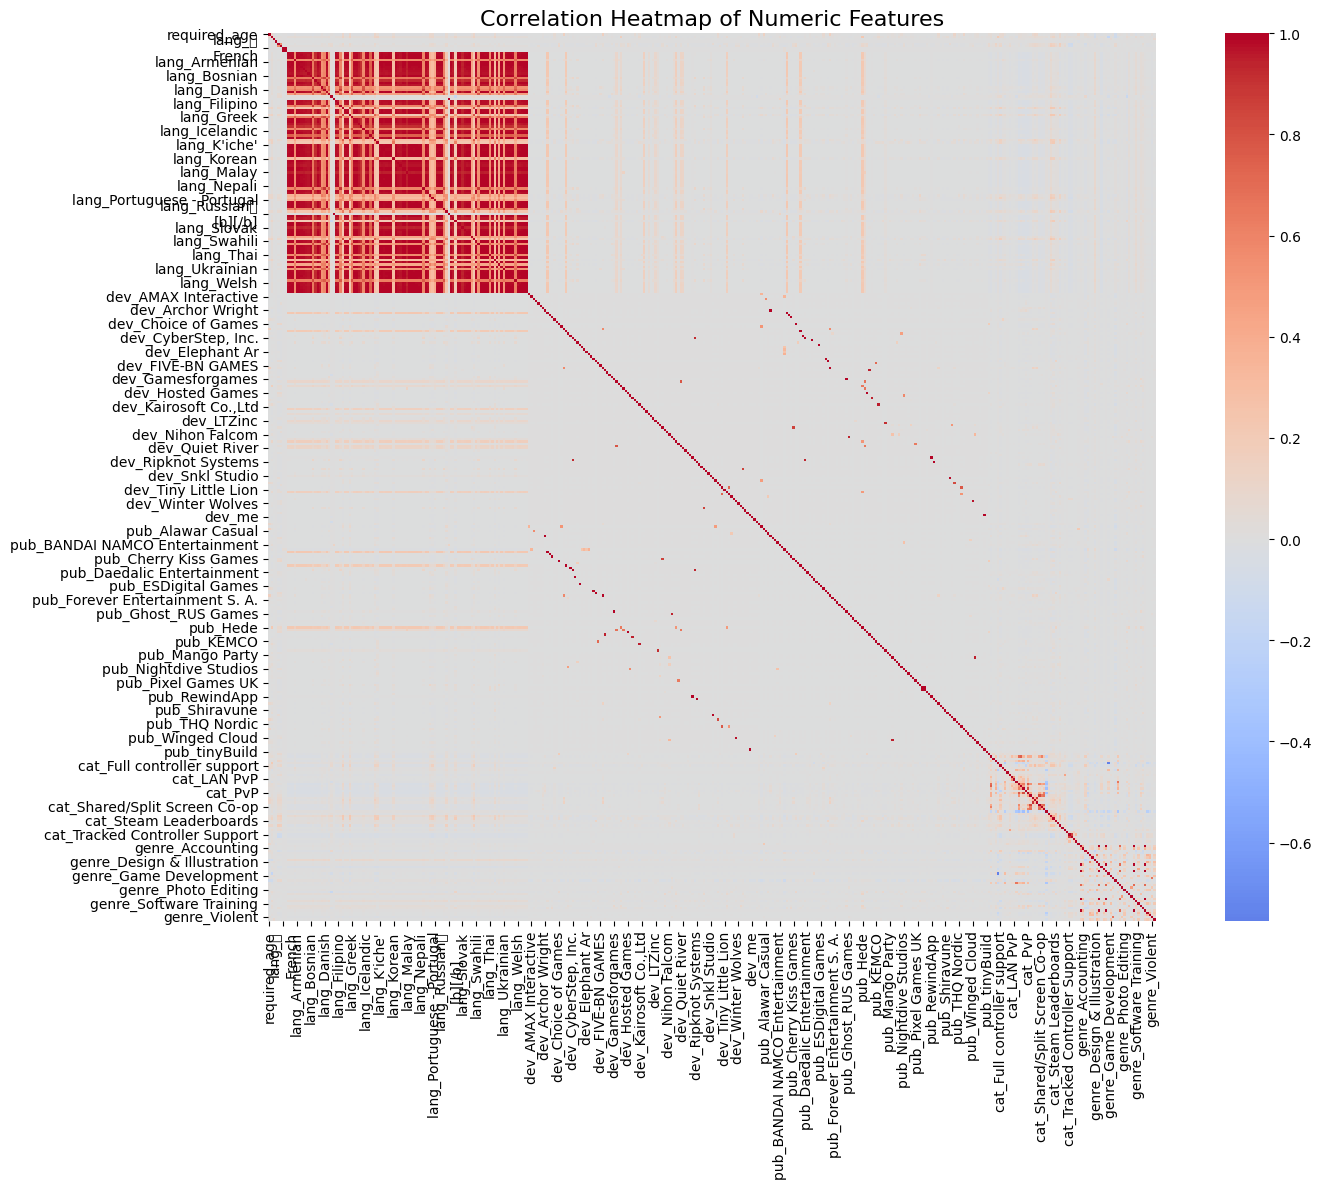

Number of numeric features: 386


In [13]:
# Create correlation heatmap
plt.figure(figsize=(16, 12))
numeric_df = df_clean.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()

print(f"Number of numeric features: {numeric_df.shape[1]}")

In [14]:
# Find strongly correlated feature pairs
corr_matrix = numeric_df.corr()
threshold = 0.9

print(f"Feature pairs with correlation > {threshold}:\n")

corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        
        if corr_value > threshold or corr_value < -threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            corr_pairs.append((col1, col2, corr_value))
            print(f"{col1:30s} <--> {col2:30s} : {corr_value:.3f}")

if len(corr_pairs) == 0:
    print("No feature pairs with correlation > 0.9 found.")

Feature pairs with correlation > 0.9:

lang_
French                  <--> lang_
German                  : 1.000
lang_Afrikaans                 <--> lang_Albanian                  : 0.982
lang_Afrikaans                 <--> lang_Amharic                   : 0.981
lang_Afrikaans                 <--> lang_Armenian                  : 0.984
lang_Afrikaans                 <--> lang_Assamese                  : 0.981
lang_Afrikaans                 <--> lang_Azerbaijani               : 0.979
lang_Afrikaans                 <--> lang_Bangla                    : 0.970
lang_Afrikaans                 <--> lang_Basque                    : 0.971
lang_Afrikaans                 <--> lang_Belarusian                : 0.967
lang_Afrikaans                 <--> lang_Bosnian                   : 0.977
lang_Afrikaans                 <--> lang_Catalan                   : 0.928
lang_Afrikaans                 <--> lang_Cherokee                  : 0.977
lang_Afrikaans                 <--> lang_Croatian              

## V. Prepare Data for Classification

Create a binary classification target variable based on a relevant threshold.
We'll classify games as "popular" (1) vs "not popular" (0) based on playtime metrics.

In [15]:
# Create a copy for modeling
df_model = df_clean.copy()

# Use average_playtime_forever as target for classification
# Create binary target: games with above-median playtime = 1 (popular), else 0
target_col = 'average_playtime_forever'

# Ensure target is numeric
df_model[target_col] = pd.to_numeric(df_model[target_col], errors='coerce')
df_model = df_model.dropna(subset=[target_col])

# Calculate median
median_playtime = df_model[target_col].median()
print(f"Median playtime: {median_playtime:.2f}")

# Create binary target variable
df_model['is_popular'] = (df_model[target_col] > median_playtime).astype(int)

print(f"\nTarget variable distribution:")
print(df_model['is_popular'].value_counts())
print(f"\nClass balance: {df_model['is_popular'].value_counts(normalize=True)}")

Median playtime: 0.00

Target variable distribution:
is_popular
0    80216
1     7915
Name: count, dtype: int64

Class balance: is_popular
0   0.91
1   0.09
Name: proportion, dtype: float64


In [16]:
# Select only numeric features (drop original playtime columns)
df_model = df_model.select_dtypes(include=['number'])

# Drop the original playtime feature
df_model = df_model.drop(columns=['average_playtime_forever'], errors='ignore')

# Handle any remaining NaNs
df_model = df_model.dropna()

print(f"Dataset shape for modeling: {df_model.shape}")
print(f"Target variable shape: {df_model['is_popular'].shape}")

Dataset shape for modeling: (88131, 387)
Target variable shape: (88131,)


## VI. Feature Normalization

Normalize features using MinMaxScaler to scale all features to [0, 1] range.
This is important for Logistic Regression and SVM classifiers.

In [17]:
# Separate features and target
X = df_model.drop(columns=['is_popular'])
y = df_model['is_popular']

# Normalize features
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
X_normalized = pd.DataFrame(X_normalized, columns=X.columns)

print(f"Features shape: {X_normalized.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature statistics after normalization:")
print(X_normalized.describe())

Features shape: (88131, 386)
Target shape: (88131,)

Feature statistics after normalization:
       required_age   price  dlc_count  windows     mac   linux  \
count       8.8e+04 8.8e+04    8.8e+04  8.8e+04 8.8e+04 8.8e+04   
mean          0.054  0.0072    0.00017        1    0.19    0.14   
std            0.08   0.013     0.0045    0.014     0.4    0.35   
min               0       0          0        0       0       0   
25%           0.045 0.00099          0        1       0       0   
50%           0.045   0.005          0        1       0       0   
75%           0.045    0.01          0        1       0       0   
max               1       1          1        1       1       1   

       lang_\r\nFrench  lang_\r\nGerman  lang_Afrikaans  lang_Albanian  ...  \
count          8.8e+04          8.8e+04         8.8e+04        8.8e+04  ...   
mean           1.1e-05          1.1e-05           0.016          0.016  ...   
std             0.0034           0.0034            0.13           

In [18]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.25, stratify=y, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set class distribution:")
print(y_train.value_counts())
print(f"\nTest set class distribution:")
print(y_test.value_counts())

Training set size: 66098
Test set size: 22033

Training set class distribution:
is_popular
0    60162
1     5936
Name: count, dtype: int64

Test set class distribution:
is_popular
0    20054
1     1979
Name: count, dtype: int64


## VII. Logistic Regression with L2 Regularization

Logistic Regression is a linear classifier that uses the sigmoid function to model
the probability of binary outcomes. L2 regularization adds a penalty for large weights.

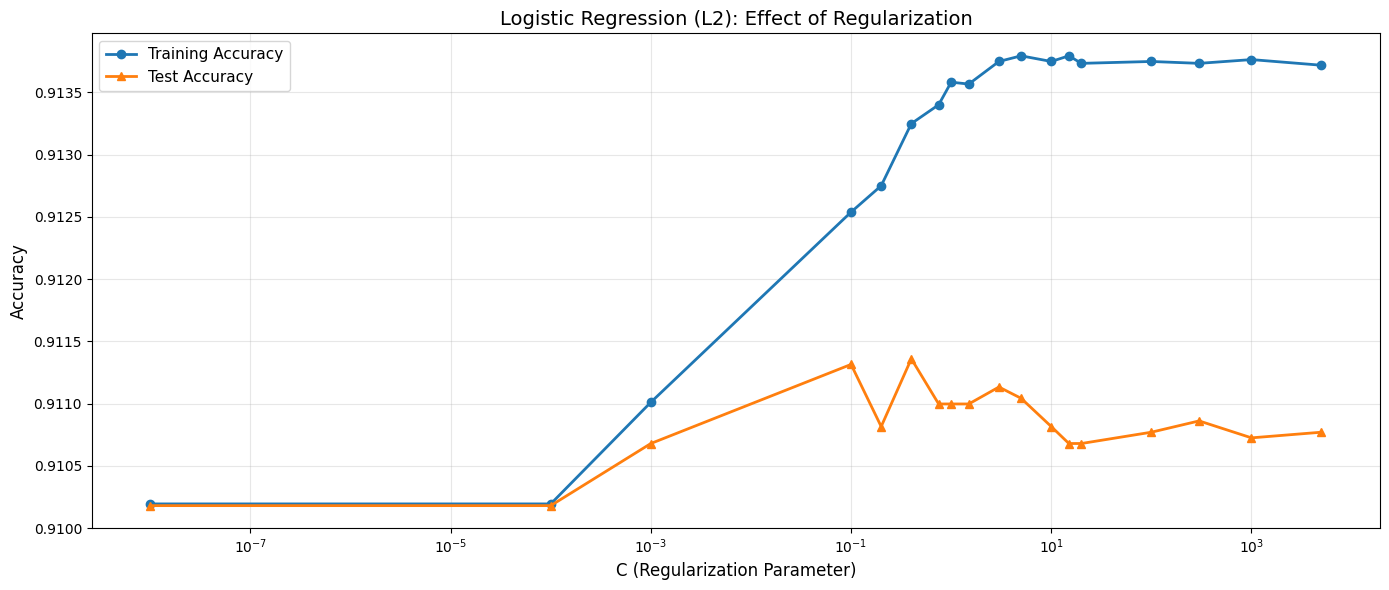

Best C for L2 Logistic Regression: 0.4
Best Test Accuracy: 0.9114


In [19]:
# Test different C values (lower C = more regularization)
C_values = [1e-8, 1e-4, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20, 100, 300, 1000, 5000]

training_accuracy_l2 = []
test_accuracy_l2 = []

for C in C_values:
    lr = LogisticRegression(C=C, solver='liblinear', random_state=42, max_iter=1000)
    lr.fit(X_train, y_train)
    
    training_accuracy_l2.append(lr.score(X_train, y_train))
    test_accuracy_l2.append(lr.score(X_test, y_test))

# Plot results
plt.figure(figsize=(14, 6))
plt.xscale('log')
plt.plot(C_values, training_accuracy_l2, marker='o', label='Training Accuracy', linewidth=2)
plt.plot(C_values, test_accuracy_l2, marker='^', label='Test Accuracy', linewidth=2)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('C (Regularization Parameter)', fontsize=12)
plt.title('Logistic Regression (L2): Effect of Regularization', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_C_l2 = C_values[np.argmax(test_accuracy_l2)]
best_test_l2 = max(test_accuracy_l2)
print(f"Best C for L2 Logistic Regression: {best_C_l2}")
print(f"Best Test Accuracy: {best_test_l2:.4f}")

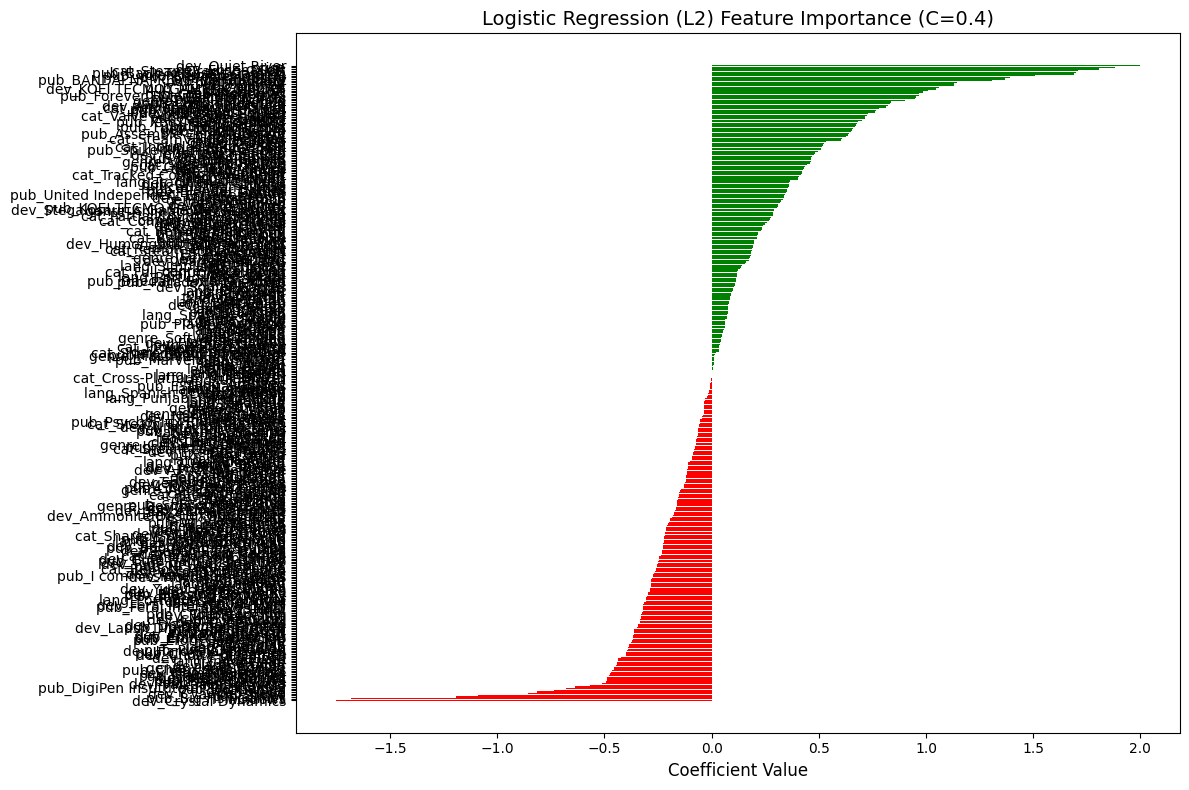


Top 5 Positive Features (increase popularity):
                       Feature  Coefficient
223  pub_Back To Basics Gaming          1.7
344    cat_Steam Trading Cards          1.7
140             dev_EnsenaSoft          1.8
1                        price          1.9
180            dev_Quiet River            2

Top 5 Negative Features (decrease popularity):
                  Feature  Coefficient
128  dev_Crystal Dynamics         -1.8
3                 windows         -1.7
224    pub_Big Fish Games         -1.2
214            pub_8floor         -1.1
130    dev_Cyanide Studio        -0.86


In [20]:
# Train best L2 model and analyze coefficients
lr_l2_best = LogisticRegression(C=best_C_l2, solver='liblinear', random_state=42, max_iter=1000)
lr_l2_best.fit(X_train, y_train)

# Feature importance
feature_importance_l2 = pd.DataFrame({
    'Feature': X_normalized.columns,
    'Coefficient': lr_l2_best.coef_[0]
}).sort_values('Coefficient')

# Plot top and bottom features
fig, ax = plt.subplots(figsize=(12, 8))
feature_importance_l2_sorted = feature_importance_l2.sort_values('Coefficient')
colors = ['red' if x < 0 else 'green' for x in feature_importance_l2_sorted['Coefficient']]
ax.barh(feature_importance_l2_sorted['Feature'], feature_importance_l2_sorted['Coefficient'], color=colors)
plt.title(f'Logistic Regression (L2) Feature Importance (C={best_C_l2})', fontsize=14)
plt.xlabel('Coefficient Value', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTop 5 Positive Features (increase popularity):")
print(feature_importance_l2.tail(5))
print(f"\nTop 5 Negative Features (decrease popularity):")
print(feature_importance_l2.head(5))

## VIII. Logistic Regression with L1 Regularization

L1 regularization encourages feature selection by shrinking some weights exactly to zero.
This helps identify the most important features.

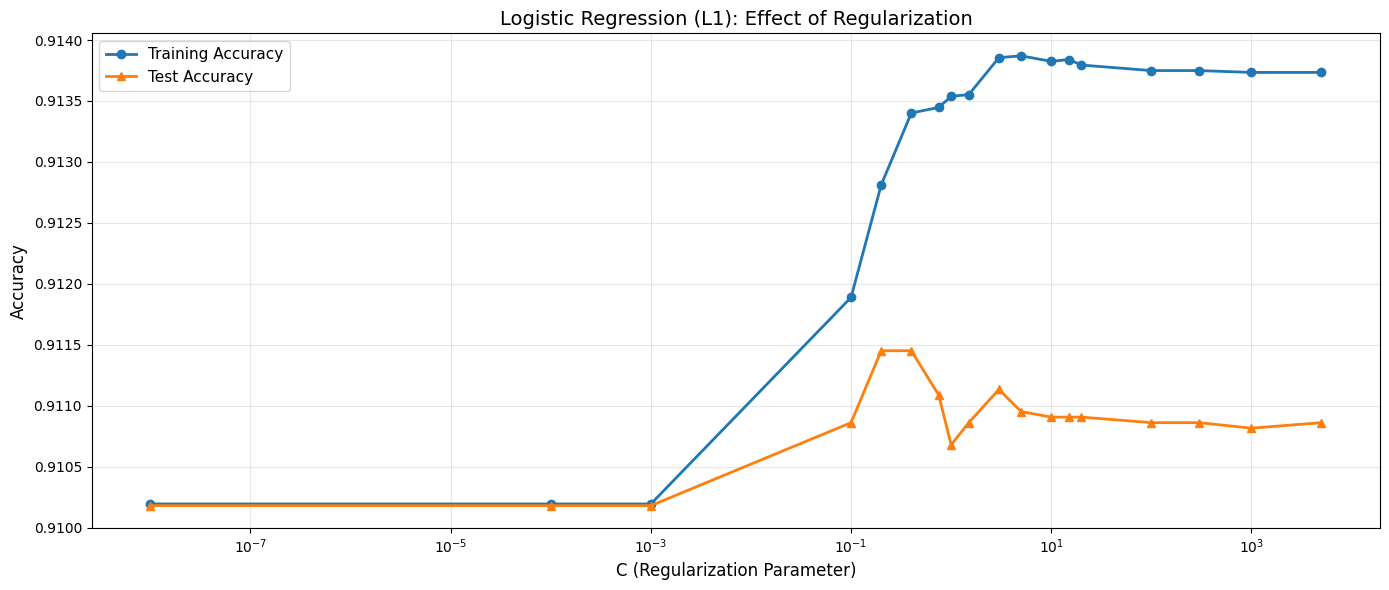

Best C for L1 Logistic Regression: 0.2
Best Test Accuracy: 0.9115


In [21]:
# Test different C values for L1
training_accuracy_l1 = []
test_accuracy_l1 = []

for C in C_values:
    lr_l1 = LogisticRegression(C=C, penalty="l1", solver='liblinear', random_state=42, max_iter=1000)
    lr_l1.fit(X_train, y_train)
    
    training_accuracy_l1.append(lr_l1.score(X_train, y_train))
    test_accuracy_l1.append(lr_l1.score(X_test, y_test))

# Plot results
plt.figure(figsize=(14, 6))
plt.xscale('log')
plt.plot(C_values, training_accuracy_l1, marker='o', label='Training Accuracy', linewidth=2)
plt.plot(C_values, test_accuracy_l1, marker='^', label='Test Accuracy', linewidth=2)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('C (Regularization Parameter)', fontsize=12)
plt.title('Logistic Regression (L1): Effect of Regularization', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_C_l1 = C_values[np.argmax(test_accuracy_l1)]
best_test_l1 = max(test_accuracy_l1)
print(f"Best C for L1 Logistic Regression: {best_C_l1}")
print(f"Best Test Accuracy: {best_test_l1:.4f}")

L1 Logistic Regression - Features selected: 112 out of 386
Sparsity: 71.0%


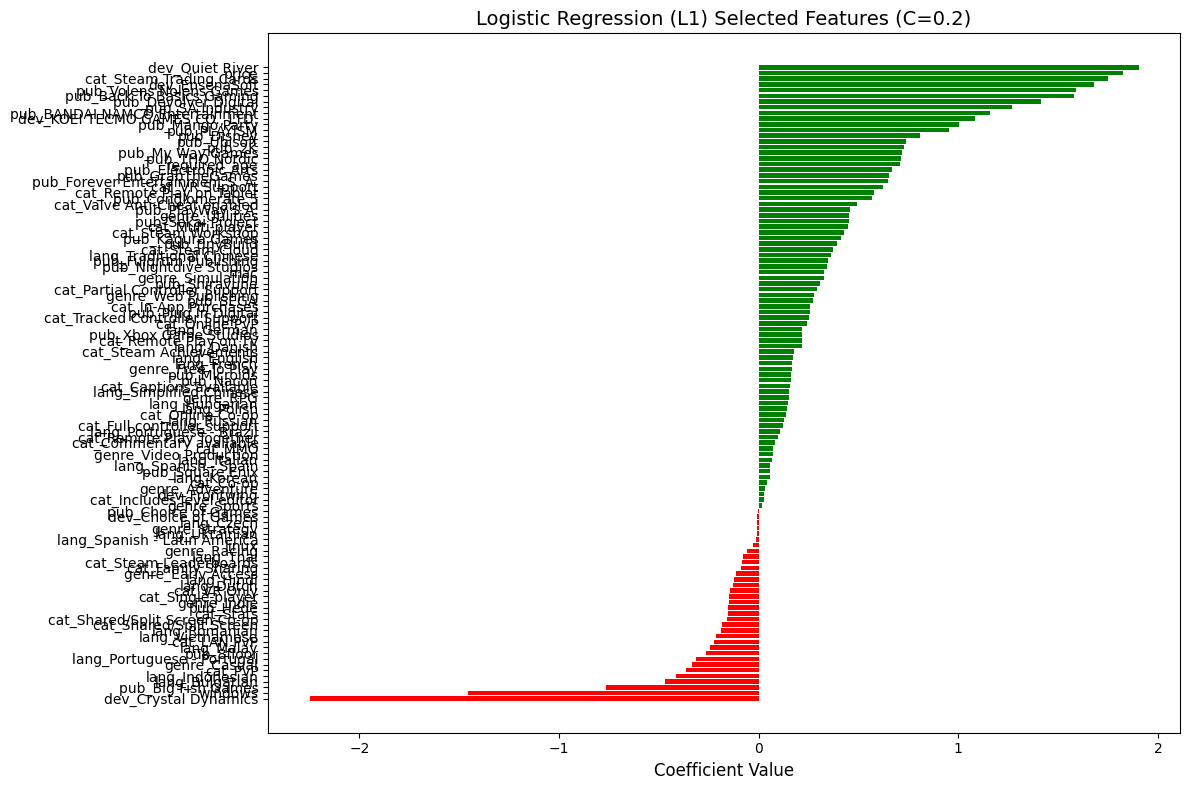


Top 5 Selected Features:
                     Feature  Coefficient
304  pub_Volens Nolens Games          1.6
140           dev_EnsenaSoft          1.7
344  cat_Steam Trading Cards          1.7
1                      price          1.8
180          dev_Quiet River          1.9


In [22]:
# Train best L1 model
lr_l1_best = LogisticRegression(C=best_C_l1, penalty="l1", solver='liblinear', random_state=42, max_iter=1000)
lr_l1_best.fit(X_train, y_train)

# Feature importance
feature_importance_l1 = pd.DataFrame({
    'Feature': X_normalized.columns,
    'Coefficient': lr_l1_best.coef_[0]
}).sort_values('Coefficient')

# Count zero coefficients (feature selection)
num_selected = np.sum(lr_l1_best.coef_[0] != 0)
print(f"L1 Logistic Regression - Features selected: {num_selected} out of {len(X_normalized.columns)}")
print(f"Sparsity: {(1 - num_selected/len(X_normalized.columns))*100:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
feature_importance_l1_sorted = feature_importance_l1[feature_importance_l1['Coefficient'] != 0].sort_values('Coefficient')
colors = ['red' if x < 0 else 'green' for x in feature_importance_l1_sorted['Coefficient']]
ax.barh(feature_importance_l1_sorted['Feature'], feature_importance_l1_sorted['Coefficient'], color=colors)
plt.title(f'Logistic Regression (L1) Selected Features (C={best_C_l1})', fontsize=14)
plt.xlabel('Coefficient Value', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTop 5 Selected Features:")
print(feature_importance_l1[feature_importance_l1['Coefficient'] != 0].tail(5))

## IX. Support Vector Machine (SVM) with L2 Regularization

SVMs find the optimal hyperplane that maximizes the margin between classes.
L2 regularization controls the trade-off between large margins and training errors.

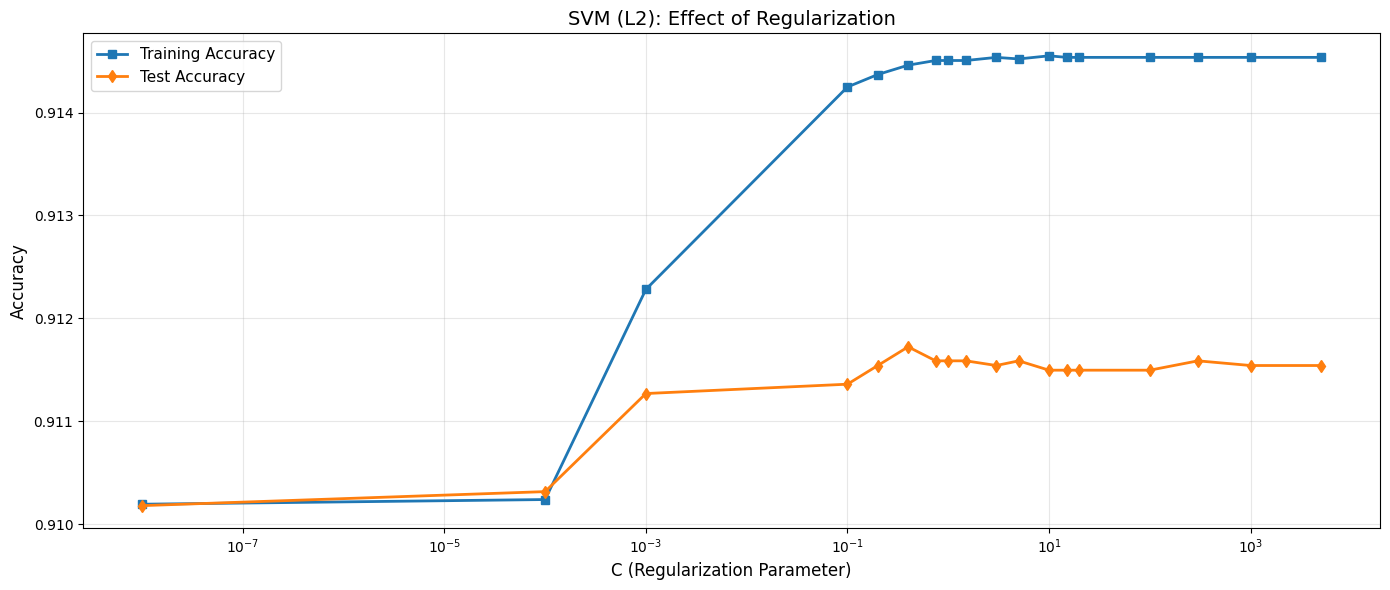

Best C for SVM L2: 0.4
Best Test Accuracy: 0.9117


In [23]:
# Test different C values for SVM L2
training_accuracy_svm_l2 = []
test_accuracy_svm_l2 = []

for C in C_values:
    svm_l2 = LinearSVC(C=C, penalty="l2", loss='squared_hinge', dual=False, random_state=42, max_iter=2000)
    svm_l2.fit(X_train, y_train)
    
    training_accuracy_svm_l2.append(svm_l2.score(X_train, y_train))
    test_accuracy_svm_l2.append(svm_l2.score(X_test, y_test))

# Plot results
plt.figure(figsize=(14, 6))
plt.xscale('log')
plt.plot(C_values, training_accuracy_svm_l2, marker='s', label='Training Accuracy', linewidth=2)
plt.plot(C_values, test_accuracy_svm_l2, marker='d', label='Test Accuracy', linewidth=2)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('C (Regularization Parameter)', fontsize=12)
plt.title('SVM (L2): Effect of Regularization', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_C_svm_l2 = C_values[np.argmax(test_accuracy_svm_l2)]
best_test_svm_l2 = max(test_accuracy_svm_l2)
print(f"Best C for SVM L2: {best_C_svm_l2}")
print(f"Best Test Accuracy: {best_test_svm_l2:.4f}")

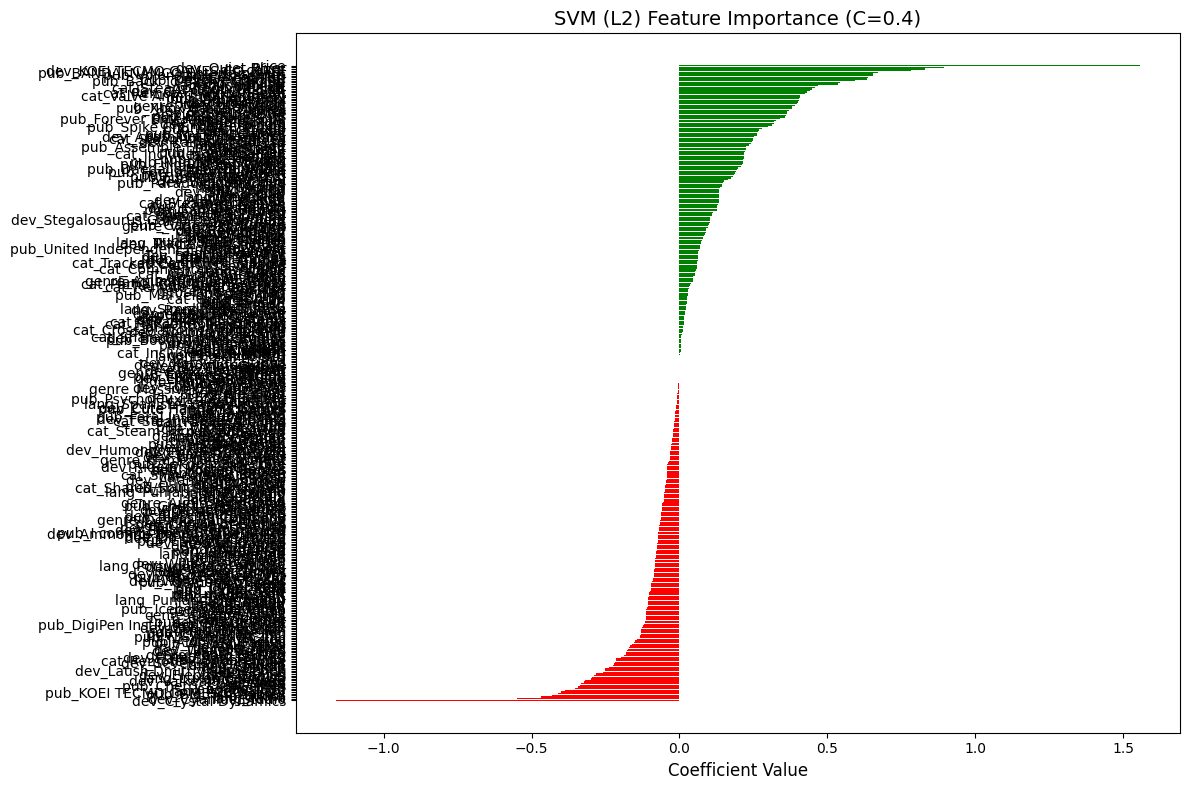


Top 5 Positive Features:
                            Feature  Coefficient
222  pub_BANDAI NAMCO Entertainment         0.67
161  dev_KOEI TECMO GAMES CO., LTD.         0.78
2                         dlc_count         0.83
180                 dev_Quiet River          0.9
1                             price          1.6

Top 5 Negative Features:
                  Feature  Coefficient
128  dev_Crystal Dynamics         -1.2
130    dev_Cyanide Studio        -0.55
93             lang_Tamil        -0.47
214            pub_8floor        -0.43
224    pub_Big Fish Games        -0.41


In [24]:
# Train best SVM L2 model
svm_l2_best = LinearSVC(C=best_C_svm_l2, penalty="l2", loss='squared_hinge', dual=False, random_state=42, max_iter=2000)
svm_l2_best.fit(X_train, y_train)

# Feature importance
feature_importance_svm_l2 = pd.DataFrame({
    'Feature': X_normalized.columns,
    'Coefficient': svm_l2_best.coef_[0]
}).sort_values('Coefficient')

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
feature_importance_svm_l2_sorted = feature_importance_svm_l2.sort_values('Coefficient')
colors = ['red' if x < 0 else 'green' for x in feature_importance_svm_l2_sorted['Coefficient']]
ax.barh(feature_importance_svm_l2_sorted['Feature'], feature_importance_svm_l2_sorted['Coefficient'], color=colors)
plt.title(f'SVM (L2) Feature Importance (C={best_C_svm_l2})', fontsize=14)
plt.xlabel('Coefficient Value', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTop 5 Positive Features:")
print(feature_importance_svm_l2.tail(5))
print(f"\nTop 5 Negative Features:")
print(feature_importance_svm_l2.head(5))

## X. Support Vector Machine (SVM) with L1 Regularization

L1 regularization in SVM also promotes sparsity, selecting important features while ignoring others.

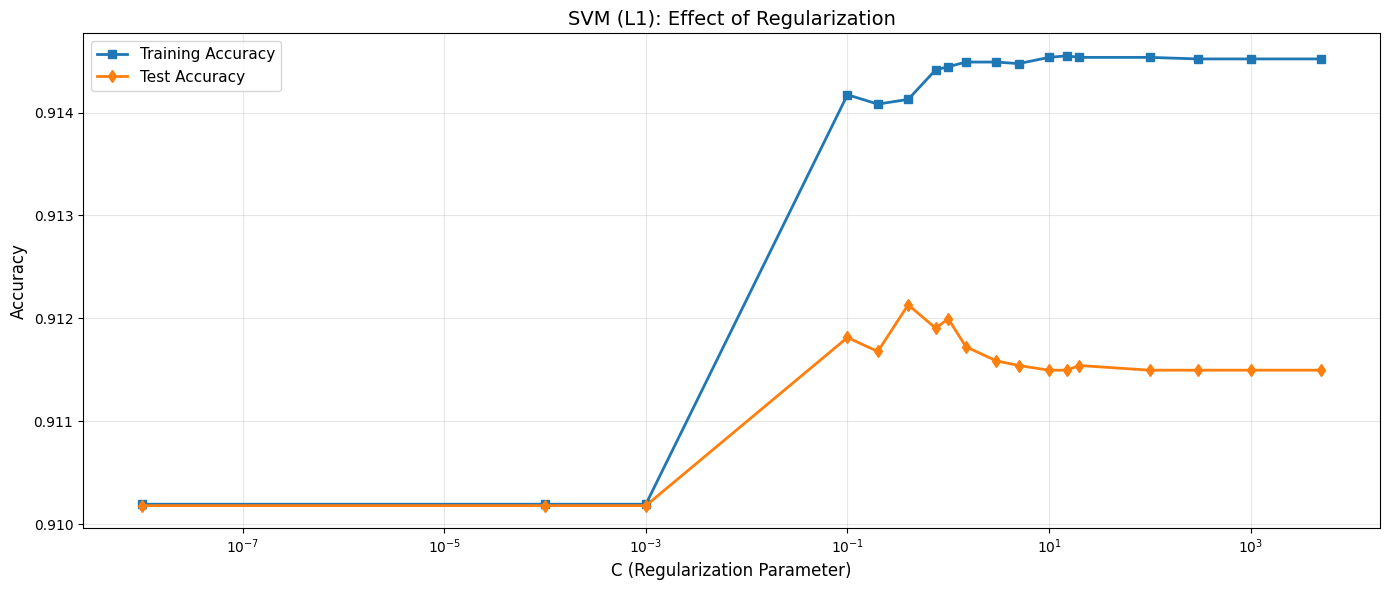

Best C for SVM L1: 0.4
Best Test Accuracy: 0.9121


In [25]:
# Test different C values for SVM L1
training_accuracy_svm_l1 = []
test_accuracy_svm_l1 = []

for C in C_values:
    try:
        svm_l1 = LinearSVC(C=C, penalty="l1", loss='squared_hinge', dual=False, random_state=42, max_iter=2000)
        svm_l1.fit(X_train, y_train)
        training_accuracy_svm_l1.append(svm_l1.score(X_train, y_train))
        test_accuracy_svm_l1.append(svm_l1.score(X_test, y_test))
    except:
        training_accuracy_svm_l1.append(0)
        test_accuracy_svm_l1.append(0)

# Plot results
plt.figure(figsize=(14, 6))
plt.xscale('log')
plt.plot(C_values, training_accuracy_svm_l1, marker='s', label='Training Accuracy', linewidth=2)
plt.plot(C_values, test_accuracy_svm_l1, marker='d', label='Test Accuracy', linewidth=2)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('C (Regularization Parameter)', fontsize=12)
plt.title('SVM (L1): Effect of Regularization', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

valid_indices = [i for i, val in enumerate(test_accuracy_svm_l1) if val > 0]
if valid_indices:
    best_idx = valid_indices[np.argmax([test_accuracy_svm_l1[i] for i in valid_indices])]
    best_C_svm_l1 = C_values[best_idx]
    best_test_svm_l1 = test_accuracy_svm_l1[best_idx]
    print(f"Best C for SVM L1: {best_C_svm_l1}")
    print(f"Best Test Accuracy: {best_test_svm_l1:.4f}")
else:
    print("L1 SVM did not converge. Using L2 results.")

## XI. Model Comparison and Evaluation

Compare the performance of Logistic Regression and SVM classifiers.

In [26]:
# Detailed evaluation of best models
models = {
    'Logistic Regression (L2)': (lr_l2_best, best_test_l2),
    'Logistic Regression (L1)': (lr_l1_best, best_test_l1),
    'SVM (L2)': (svm_l2_best, best_test_svm_l2),
}

# Summary table
summary_data = []
for name, (model, test_acc) in models.items():
    y_pred = model.predict(X_test)
    
    summary_data.append({
        'Model': name,
        'Train Accuracy': f"{model.score(X_train, y_train):.4f}",
        'Test Accuracy': f"{model.score(X_test, y_test):.4f}",
        'Precision': f"{precision_score(y_test, y_pred):.4f}",
        'Recall': f"{recall_score(y_test, y_pred):.4f}",
        'F1-Score': f"{f1_score(y_test, y_pred):.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\nModel Performance Summary:")
print(summary_df.to_string(index=False))


Model Performance Summary:
                   Model Train Accuracy Test Accuracy Precision Recall F1-Score
Logistic Regression (L2)         0.9133        0.9114    0.5204 0.1678   0.2537
Logistic Regression (L1)         0.9128        0.9115    0.5228 0.1622   0.2476
                SVM (L2)         0.9145        0.9117    0.5417 0.1117   0.1852


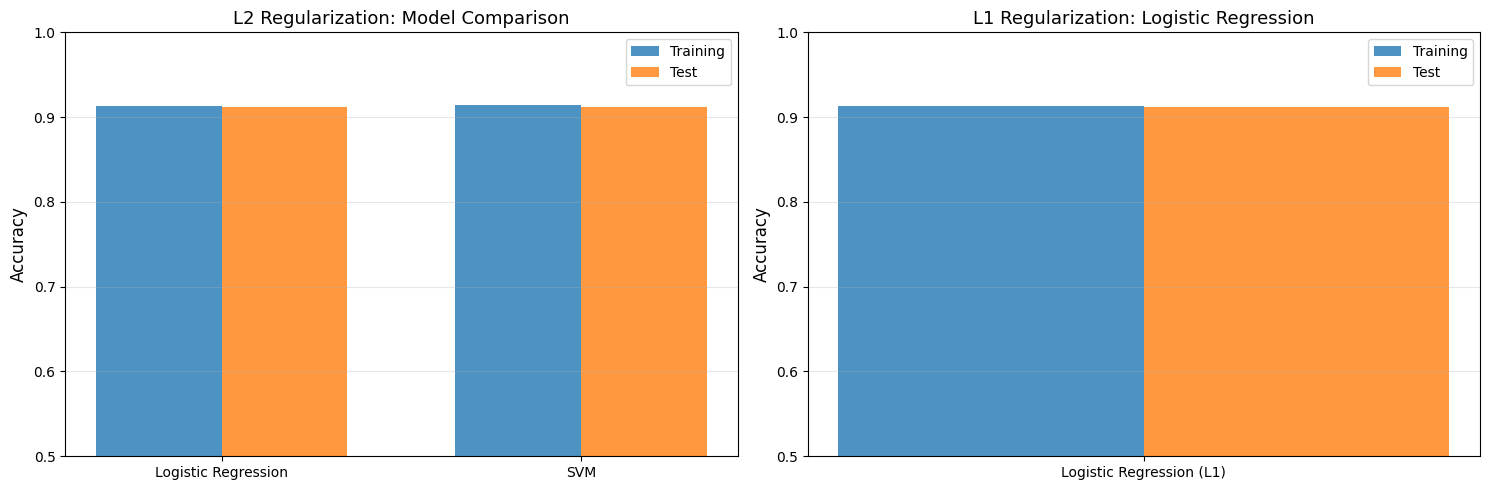

In [27]:
# Plot accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# L2 Comparison
models_l2 = ['Logistic Regression', 'SVM']
train_l2 = [lr_l2_best.score(X_train, y_train), svm_l2_best.score(X_train, y_train)]
test_l2 = [lr_l2_best.score(X_test, y_test), svm_l2_best.score(X_test, y_test)]

x = np.arange(len(models_l2))
width = 0.35
axes[0].bar(x - width/2, train_l2, width, label='Training', alpha=0.8)
axes[0].bar(x + width/2, test_l2, width, label='Test', alpha=0.8)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('L2 Regularization: Model Comparison', fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_l2)
axes[0].legend()
axes[0].set_ylim([0.5, 1.0])
axes[0].grid(axis='y', alpha=0.3)

# L1 Comparison
models_l1 = ['Logistic Regression (L1)', 'SVM (L1)']
train_l1 = [lr_l1_best.score(X_train, y_train)]
test_l1 = [lr_l1_best.score(X_test, y_test)]

x_l1 = np.arange(len(train_l1))
axes[1].bar(x_l1 - width/2, train_l1, width, label='Training', alpha=0.8)
axes[1].bar(x_l1 + width/2, test_l1, width, label='Test', alpha=0.8)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('L1 Regularization: Logistic Regression', fontsize=13)
axes[1].set_xticks(x_l1)
axes[1].set_xticklabels(['Logistic Regression (L1)'])
axes[1].legend()
axes[1].set_ylim([0.5, 1.0])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

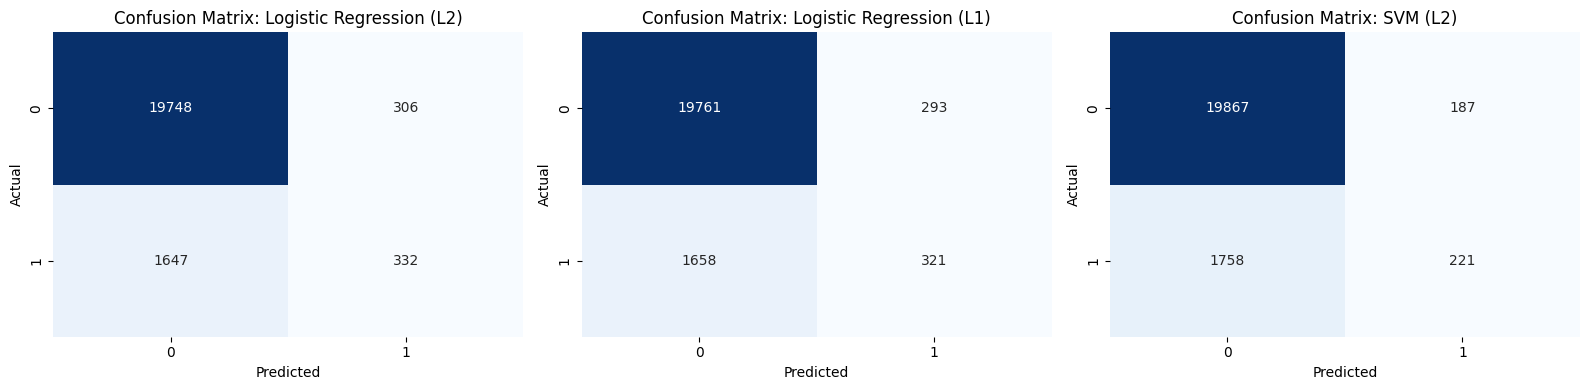

In [28]:
# Confusion matrices for best models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models_to_plot = [
    ('Logistic Regression (L2)', lr_l2_best),
    ('Logistic Regression (L1)', lr_l1_best),
    ('SVM (L2)', svm_l2_best)
]

for idx, (name, model) in enumerate(models_to_plot):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Confusion Matrix: {name}', fontsize=12)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

## XII. Key Findings and Conclusions

### Summary:
This analysis applied Logistic Regression and SVM classifiers to predict game popularity on Steam.

### Important Observations:

1. **Regularization Effect**: Both L1 and L2 regularization help prevent overfitting by adding penalties to large weights.

2. **Feature Selection**: L1 regularization promotes sparsity, automatically selecting important features by shrinking others to zero.

3. **Model Comparison**: 
   - Logistic Regression typically offers good interpretability
   - SVM can find complex decision boundaries
   - Both benefit from proper feature scaling

4. **Hyperparameter Tuning**: The C parameter (inverse of regularization strength) significantly impacts model performance.

5. **Data Preprocessing**: Proper data cleaning and correlation analysis are critical for model success.